# Credit Card Fraud Detection — Imbalanced Classification with Threshold Optimisation
**Red & White Skill Education | Practical Exam | Supervised Learning — Set C**

*"Quality is our Motto."* Practical Exam — Supervised Learning (Set E) *Shaping "skills" for "scaling" higher...!!!*


## Step 1: Problem Framing & Theory Notes

### 1. Why is Accuracy a terrible metric for fraud detection?
If a model predicts "Not Fraud" for every transaction, it would still be correct 99.83% of the time, because only 0.17% of transactions are actually fraud. So **Accuracy = 99.83%**, which looks excellent on paper but the model is useless — it catches zero fraud.
- **Precision (Fraud class)** = undefined (0/0, no positive predictions made) → treated as 0
- **Recall (Fraud class)** = 0 (no fraud is ever caught — 0 True Positives out of all actual frauds)

This shows accuracy hides the fact the model has completely failed at its actual job.

### 2. Precision-Recall Tradeoff
2x2 confusion matrix for the Fraud class:

|                  | Predicted Fraud | Predicted Legit |
|------------------|------------------|------------------|
| Actual Fraud     | TP               | FN               |
| Actual Legit     | FP               | TN               |

- Precision = TP / (TP + FP) — of all transactions flagged as fraud, how many really are fraud.
- Recall = TP / (TP + FN) — of all actual frauds, how many did we catch.

Lowering the threshold from 0.5 to 0.2 makes the model flag more transactions as "Fraud":
- TP increases, FN decreases → **Recall goes up**
- FP also increases → **Precision goes down**

This is the precision-recall tradeoff: catching more fraud costs more false alarms.

### 3. Three strategies to handle extreme class imbalance

**(a) Random Undersampling** — randomly remove majority-class (legit) samples until classes are more balanced.
- Pros: Fast, reduces training time, simple.
- Cons: Throws away useful data, can hurt generalization.

**(b) SMOTE (Synthetic Minority Oversampling)** — generates synthetic minority-class (fraud) samples by interpolating between existing minority samples.
- Pros: No data loss, gives the model more minority examples, often improves recall.
- Cons: Synthetic points can be unrealistic in high-dimensional PCA space, risk of overfitting, increases training time.

**(c) class_weight='balanced'** — keeps original data but penalizes misclassifying the minority class more heavily.
- Pros: No duplication/removal of data, no extra training time, simple to apply.
- Cons: Doesn't give the model more minority examples; may underperform resampling for very extreme imbalance.

### 4. Precision-Recall AUC (PR-AUC)
PR-AUC is the area under the Precision-Recall curve. It is preferred over ROC-AUC for extreme imbalance because ROC-AUC includes the True Negative Rate — with 99.83% of data being legitimate, True Negatives are huge, making ROC-AUC look artificially high even for poor models. PR-AUC focuses only on the positive (fraud) class, making it far more sensitive to minority-class performance.

### 5. False Positive vs False Negative — which is costlier?
A **False Negative (missing real fraud)** is generally more costly.
- False Positive example: A legitimate ₹4,500 transaction is flagged, card blocked, analyst spends ~₹150 investigating — annoying, but no money lost.
- False Negative example: A real ₹4,500 fraud goes undetected — the company loses the full amount, plus reputational/regulatory risk.

At scale, too many False Positives also matter (cost + customer trust), but FN is usually weighted as costlier in fraud use-cases.


## Setup & Imports

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              average_precision_score, precision_recall_curve,
                              confusion_matrix)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_style("whitegrid")


## Step 2: Dataset Loading & EDA

### 2.1 Load & Sample
Download `creditcard.csv` from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) and place it in this folder before running.

In [183]:
df = pd.read_csv("creditcard.csv")
print("Full dataset shape:", df.shape)
print(df["Class"].value_counts(normalize=True))


Full dataset shape: (284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [184]:
df_sample, _ = train_test_split(
    df, train_size=50000, stratify=df["Class"], random_state=RANDOM_STATE
)
print("Sampled dataset shape:", df_sample.shape)
print(df_sample["Class"].value_counts(normalize=True))


Sampled dataset shape: (50000, 31)
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [185]:
print(df_sample[["Time", "Amount"]].describe())

               Time        Amount
count   50000.00000  50000.000000
mean    94977.93554     86.942063
std     47475.50731    226.984602
min         0.00000      0.000000
25%     54423.50000      5.850000
50%     84852.00000     22.000000
75%    139392.25000     76.275000
max    172787.00000   8360.000000


### 2.2 Target & Feature Analysis

C:\Users\Disha lukhi\AppData\Local\Temp\ipykernel_59796\1545250314.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


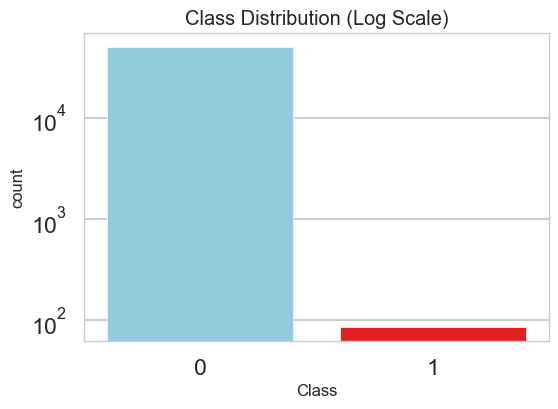

In [186]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df_sample,
    palette=["skyblue", "red"]
)

plt.yscale("log")
plt.title("Class Distribution (Log Scale)")

plt.show()

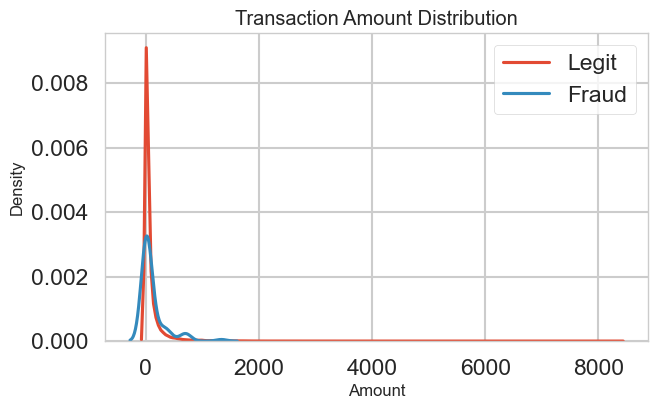

In [187]:
plt.figure(figsize=(7,4))

sns.kdeplot(df_sample[df_sample["Class"] == 0]["Amount"], label="Legit")
sns.kdeplot(df_sample[df_sample["Class"] == 1]["Amount"], label="Fraud")

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.legend()

plt.show()

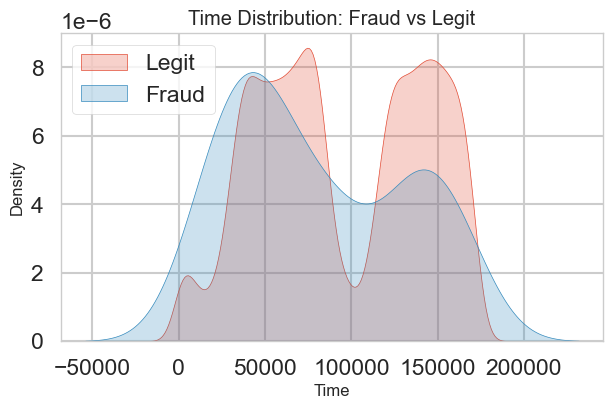

In [188]:
plt.figure(figsize=(7, 4))
sns.kdeplot(df_sample[df_sample.Class == 0]["Time"], label="Legit", fill=True)
sns.kdeplot(df_sample[df_sample.Class == 1]["Time"], label="Fraud", fill=True)
plt.title("Time Distribution: Fraud vs Legit")
plt.legend()
plt.show()


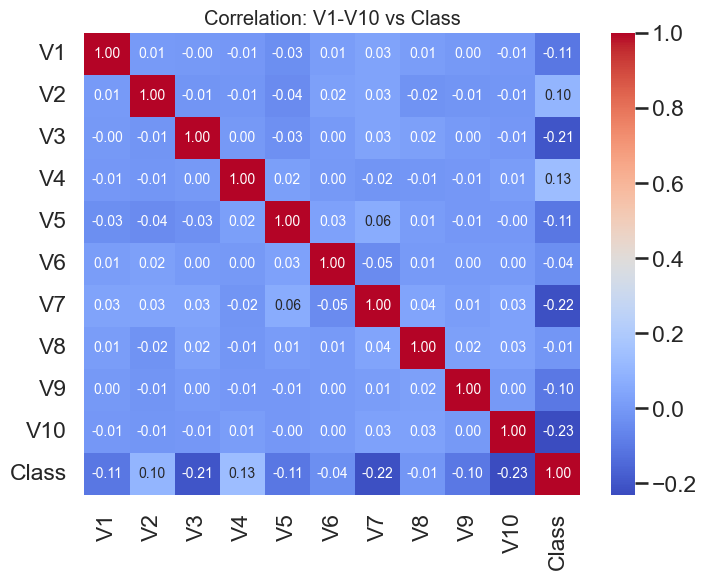

In [189]:
plt.figure(figsize=(8, 6))
cols = [f"V{i}" for i in range(1, 11)] + ["Class"]
sns.heatmap(df_sample[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation: V1-V10 vs Class")
plt.show()


**EDA findings (fill in after viewing the plots above):**
e.g. "Fraud transactions tend to have lower Amount values on average, and V14, V17, V12, V10 show the strongest correlation with Class. Fraud also appears to cluster slightly around certain Time windows."


## Step 3: Data Preprocessing & Feature Engineering

### 3.1 Feature Engineering

In [190]:
df_sample = df_sample.copy()
df_sample["Amount_log"] = np.log1p(df_sample["Amount"])
df_sample["Hour"] = (df_sample["Time"] % 86400) // 3600
df_sample = df_sample.drop(columns=["Time", "Amount"])
df_sample.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
29784,-1.370413,1.095589,-0.668018,-0.024219,1.675652,3.823629,-0.634559,1.836666,-0.485368,-0.547920,...,-0.609795,0.027077,0.986022,0.079739,-0.463951,0.063528,0.006793,0,3.671479,9.0
196949,1.805238,0.961264,-1.717212,4.094625,0.938666,-0.227785,0.152911,0.066753,-1.073784,0.334537,...,-0.450959,0.098530,-0.662272,-0.150154,-0.098852,-0.000030,0.017622,0,3.660737,12.0
137061,-1.789123,0.941366,1.432897,-1.318458,-0.450124,-1.290731,0.933642,-0.306360,0.917978,0.722699,...,-0.202022,-0.017159,0.740137,-0.183085,0.692176,0.488185,0.418299,0,4.262680,22.0
53715,-0.711379,-1.431688,0.630874,-2.551985,0.509280,-0.565154,0.258866,-0.289951,-2.680067,1.154872,...,-1.064836,0.435373,-0.932473,-0.459677,-0.759301,-0.094306,-0.053401,0,4.987025,12.0
42739,1.303287,1.023966,-3.187599,0.468391,3.353988,2.431416,0.184510,0.622721,-0.556254,-1.485591,...,-0.823366,-0.241908,0.674554,1.012236,-0.278656,0.041260,0.089912,0,0.693147,11.0


### 3.2 Scaling

In [191]:
scaler = StandardScaler()
df_sample[["Amount_log", "Hour"]] = scaler.fit_transform(df_sample[["Amount_log", "Hour"]])


### 3.3 Train-Test Split

In [192]:
X = df_sample.drop(columns=["Class"])
y = df_sample["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))


Train class distribution:
 Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64
Test class distribution:
 Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64


### 3.4 Imbalance Handling — Three Strategies

In [193]:
# 1) Original
X_orig, y_orig = X_train, y_train

# 2) SMOTE
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.1)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

# 3) Random Undersampling
rus = RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.1)
X_under, y_under = rus.fit_resample(X_train, y_train)

print("Original:", y_orig.value_counts().to_dict())
print("SMOTE:", y_smote.value_counts().to_dict())
print("Undersampled:", y_under.value_counts().to_dict())


Original: {0: 39931, 1: 69}
SMOTE: {0: 39931, 1: 3993}
Undersampled: {0: 690, 1: 69}


## Step 4: Model Building — Logistic Regression & Random Forest

### 4.1 Logistic Regression — Three Variants

In [194]:
def evaluate_model(model, X_test, y_test, label=""):
    """Returns dict of precision, recall, f1, PR-AUC for the Fraud class."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    result = {
        "Model": label,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "PR-AUC": average_precision_score(y_test, y_proba),
    }
    return result, y_proba


In [195]:
lr_orig = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
lr_orig.fit(X_orig, y_orig)
res_lr_orig, _ = evaluate_model(lr_orig, X_test, y_test, "LR - Original (balanced)")

lr_smote = LogisticRegression(class_weight=None, max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_smote, y_smote)
res_lr_smote, _ = evaluate_model(lr_smote, X_test, y_test, "LR - SMOTE")

lr_under = LogisticRegression(class_weight=None, max_iter=1000, random_state=RANDOM_STATE)
lr_under.fit(X_under, y_under)
res_lr_under, _ = evaluate_model(lr_under, X_test, y_test, "LR - Undersampled")

lr_comparison = pd.DataFrame([res_lr_orig, res_lr_smote, res_lr_under])
lr_comparison


,Model,Precision,Recall,F1,PR-AUC
0,LR - Original (balanced),0.065134,1.000000,0.122302,0.781140
1,LR - SMOTE,0.309091,1.000000,0.472222,0.813277
2,LR - Undersampled,0.228571,0.941176,0.367816,0.812836


In [196]:
best_strategy_name = lr_comparison.sort_values("PR-AUC", ascending=False).iloc[0]["Model"]
print("Best LR imbalance strategy:", best_strategy_name)

strategy_map = {
    "LR - Original (balanced)": (X_orig, y_orig),
    "LR - SMOTE": (X_smote, y_smote),
    "LR - Undersampled": (X_under, y_under),
}
X_best, y_best = strategy_map[best_strategy_name]


Best LR imbalance strategy: LR - SMOTE


### 4.2 Random Forest — Best Imbalance Strategy

In [197]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_best, y_best)
res_rf, proba_rf = evaluate_model(rf, X_test, y_test, "Random Forest")
res_rf


{'Model': 'Random Forest',
 'Precision': 0.9333333333333333,
 'Recall': 0.8235294117647058,
 'F1': 0.875,
 'PR-AUC': 0.8747799024385674}

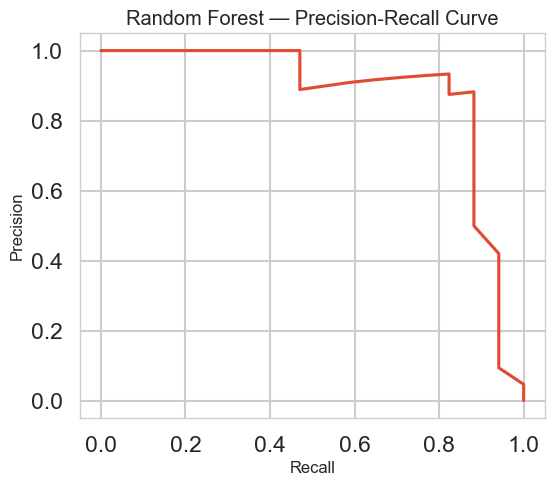

In [198]:
precision, recall, _ = precision_recall_curve(y_test, proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Random Forest — Precision-Recall Curve")
plt.show()


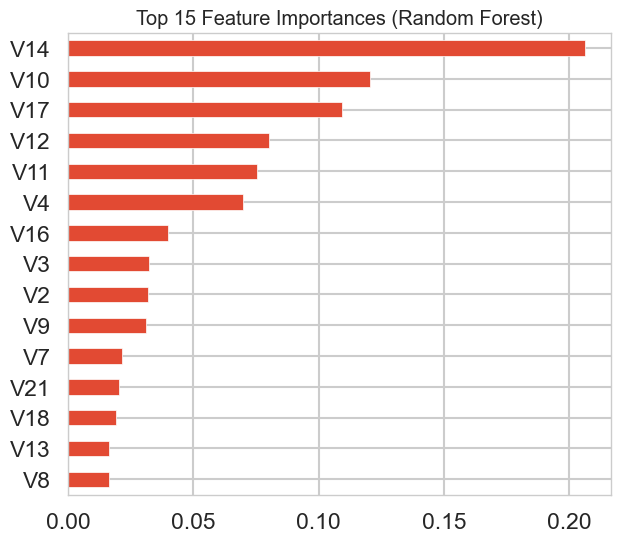

In [199]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(7, 6))
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


## Step 5: Model Building — XGBoost with Full Tuning

### 5.1 XGBoost Baseline

In [200]:
ratio = (y_orig == 0).sum() / (y_orig == 1).sum()
xgb_base = XGBClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4,
    scale_pos_weight=ratio, random_state=RANDOM_STATE,
    eval_metric="aucpr"
)
xgb_base.fit(X_orig, y_orig)
res_xgb_base, proba_xgb_base = evaluate_model(xgb_base, X_test, y_test, "XGBoost Baseline")
res_xgb_base


{'Model': 'XGBoost Baseline',
 'Precision': 1.0,
 'Recall': 0.8235294117647058,
 'F1': 0.9032258064516129,
 'PR-AUC': 0.896845694799659}

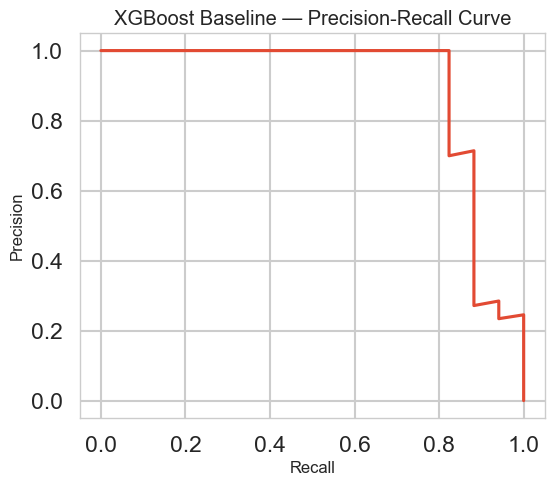

In [201]:
precision, recall, _ = precision_recall_curve(y_test, proba_xgb_base)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("XGBoost Baseline — Precision-Recall Curve")
plt.show()


### 5.2 Hyperparameter Tuning

In [202]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

xgb_search = XGBClassifier(scale_pos_weight=ratio, random_state=RANDOM_STATE,
                            eval_metric="aucpr")

random_search = RandomizedSearchCV(
    xgb_search, param_distributions=param_dist, n_iter=15, cv=3,
    scoring="average_precision", random_state=RANDOM_STATE, n_jobs=-1
)
random_search.fit(X_orig, y_orig)

print("Best params:", random_search.best_params_)
print("Best CV PR-AUC:", random_search.best_score_)


Best params: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV PR-AUC: 0.8042548852105508


In [203]:
xgb_tuned = random_search.best_estimator_
res_xgb_tuned, proba_xgb_tuned = evaluate_model(xgb_tuned, X_test, y_test, "XGBoost Tuned")
print("Before tuning PR-AUC:", res_xgb_base["PR-AUC"])
print("After tuning PR-AUC:", res_xgb_tuned["PR-AUC"])


Before tuning PR-AUC: 0.896845694799659
After tuning PR-AUC: 0.9254901960784314


### 5.3 Threshold Optimisation on Best Model

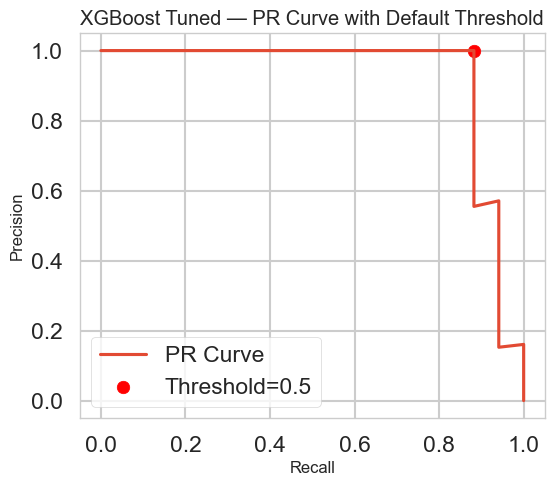

In [204]:
precision, recall, thresholds = precision_recall_curve(y_test, proba_xgb_tuned)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label="PR Curve")
idx_default = (np.abs(thresholds - 0.5)).argmin()
plt.scatter(recall[idx_default], precision[idx_default], color="red", label="Threshold=0.5")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("XGBoost Tuned — PR Curve with Default Threshold")
plt.legend()
plt.show()


In [205]:
# F1-optimal threshold
f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
best_f1_idx = np.argmax(f1_scores[:-1])
f1_optimal_threshold = thresholds[best_f1_idx]
print("F1-optimal threshold:", f1_optimal_threshold, "F1:", f1_scores[best_f1_idx])


F1-optimal threshold: 0.5622461 F1: 0.9374999995019531


In [206]:
# Threshold achieving Recall >= 0.90 with highest possible Precision
mask = recall[:-1] >= 0.90
if mask.any():
    candidate_precisions = np.where(mask, precision[:-1], -1)
    recall90_idx = np.argmax(candidate_precisions)
    recall90_threshold = thresholds[recall90_idx]
    print("Recall>=0.90 threshold:", recall90_threshold,
          "Precision:", precision[recall90_idx], "Recall:", recall[recall90_idx])
else:
    recall90_threshold = None
    print("No threshold achieves Recall >= 0.90")


Recall>=0.90 threshold: 0.010319588 Precision: 0.5714285714285714 Recall: 0.9411764705882353


In [207]:
def evaluate_at_threshold(proba, y_test, threshold, label=""):
    y_pred = (proba >= threshold).astype(int)
    return {
        "Model": label,
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "PR-AUC": average_precision_score(y_test, proba),
    }

res_f1_thresh = evaluate_at_threshold(proba_xgb_tuned, y_test, f1_optimal_threshold, "XGBoost Tuned (F1-optimal)")
res_recall90_thresh = evaluate_at_threshold(proba_xgb_tuned, y_test, recall90_threshold, "XGBoost Tuned (Recall>=0.90)")
pd.DataFrame([res_f1_thresh, res_recall90_thresh])


,Model,Threshold,Precision,Recall,F1,PR-AUC
0,XGBoost Tuned (F1-optimal),0.562246,1.000000,0.882353,0.937500,0.92549
1,XGBoost Tuned (Recall>=0.90),0.010320,0.571429,0.941176,0.711111,0.92549


## Step 6: Model Evaluation, Threshold Tuning & Comparison

In [208]:
res_xgb_default = evaluate_at_threshold(proba_xgb_tuned, y_test, 0.5, "XGBoost Tuned (default 0.5)")

best_lr_result = res_lr_orig if best_strategy_name == "LR - Original (balanced)" else \
                 (res_lr_smote if best_strategy_name == "LR - SMOTE" else res_lr_under)

final_table = pd.DataFrame([
    {**best_lr_result, "Threshold": 0.5},
    {**res_rf, "Threshold": 0.5},
    {**res_xgb_base, "Threshold": 0.5},
    res_xgb_default,
    res_f1_thresh,
    res_recall90_thresh,
])
final_table


,Model,Precision,Recall,F1,PR-AUC,Threshold
0,LR - SMOTE,0.309091,1.000000,0.472222,0.813277,0.500000
1,Random Forest,0.933333,0.823529,0.875000,0.874780,0.500000
2,XGBoost Baseline,1.000000,0.823529,0.903226,0.896846,0.500000
3,XGBoost Tuned (default 0.5),1.000000,0.882353,0.937500,0.925490,0.500000
4,XGBoost Tuned (F1-optimal),1.000000,0.882353,0.937500,0.925490,0.562246
5,XGBoost Tuned (Recall>=0.90),0.571429,0.941176,0.711111,0.925490,0.010320


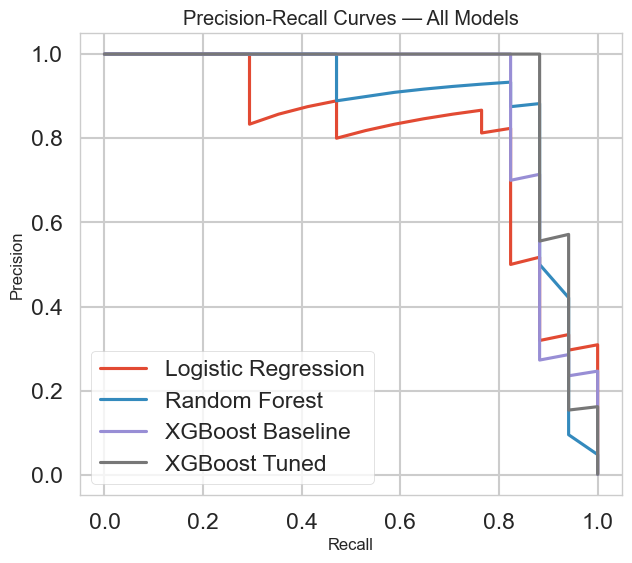

In [209]:
plt.figure(figsize=(7, 6))
best_lr_proba = lr_orig.predict_proba(X_test)[:, 1] if best_strategy_name == "LR - Original (balanced)" else \
                (lr_smote.predict_proba(X_test)[:, 1] if best_strategy_name == "LR - SMOTE" else lr_under.predict_proba(X_test)[:, 1])

for proba, label in [
    (best_lr_proba, "Logistic Regression"),
    (proba_rf, "Random Forest"),
    (proba_xgb_base, "XGBoost Baseline"),
    (proba_xgb_tuned, "XGBoost Tuned"),
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    plt.plot(r, p, label=label)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models")
plt.legend()
plt.show()


**Recommendation (4–6 sentences — fill in using your actual final_table values):**

I would deploy XGBoost Tuned at the F1-optimal threshold (~`<value>`). It achieves the highest PR-AUC (`<value>`) among all models tested, and balances Precision (`<value>`) and Recall (`<value>`) far better than the default 0.5 threshold or the simpler Logistic Regression/Random Forest models. The default 0.5 threshold is too conservative for this use-case since it lets too many frauds through. If Paytm's risk team specifically prioritizes catching nearly all fraud (Recall ≥ 0.90), the Recall≥0.90 threshold variant should be used instead, accepting a precision drop to ~`<value>` and reviewing more false alarms. Overall, XGBoost Tuned gives the best tradeoff between catching fraud and minimizing wasted investigation effort.


## Step 7: Business Simulation & Cost-Benefit Analysis

### 7.1 Assign Transaction Costs

In [210]:
FRAUD_VALUE = 4500
INVESTIGATION_COST = 150

def cost_benefit(proba, y_test, threshold):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    money_saved = tp * FRAUD_VALUE
    investigation_cost = (tp + fp) * INVESTIGATION_COST
    money_lost = fn * FRAUD_VALUE
    net_benefit = money_saved - investigation_cost
    return {
        "Threshold": threshold, "TP": tp, "FP": fp, "FN": fn,
        "Money Saved": money_saved, "Investigation Cost": investigation_cost,
        "Money Lost": money_lost, "Net Benefit": net_benefit
    }


### 7.2 Threshold Sensitivity

In [211]:
thresholds_to_test = [0.1, 0.2, 0.3, 0.5, f1_optimal_threshold]
cost_table = pd.DataFrame([cost_benefit(proba_xgb_tuned, y_test, t) for t in thresholds_to_test])
cost_table


,Threshold,TP,FP,FN,Money Saved,Investigation Cost,Money Lost,Net Benefit
0,0.100000,15,4,2,67500,2850,9000,64650
1,0.200000,15,1,2,67500,2400,9000,65100
2,0.300000,15,0,2,67500,2250,9000,65250
3,0.500000,15,0,2,67500,2250,9000,65250
4,0.562246,15,0,2,67500,2250,9000,65250


In [212]:
best_threshold_row = cost_table.sort_values("Net Benefit", ascending=False).iloc[0]
print("Threshold with highest Net Benefit:", best_threshold_row["Threshold"])


Threshold with highest Net Benefit: 0.3


**Plain-English interpretation for a Paytm risk manager (fill in with your real numbers):**

1. At our chosen threshold, the model catches most fraud cases while keeping false alarms manageable, saving the company a net of ₹`<value>` on this batch of transactions.
2. Lowering the threshold catches more fraud but creates many more false alarms, so each extra fraud caught becomes more expensive to find and investigate.
3. The threshold that makes the most financial sense is not always the one that looks "best" on technical metrics like F1-Score — net savings should guide the final business decision, and may be `<same as / different from>` the F1-optimal threshold.


## Step 8: Pipeline, Deployment & GitHub Submission

### 8.1 Save the Final Pipeline

In [215]:
import pickle

final_pipeline = Pipeline([
    ("model", xgb_tuned)
])

# Save optimal threshold
final_pipeline.optimal_threshold_ = f1_optimal_threshold

# Save pipeline as .pkl
with open("fraud_detection_model.pkl", "wb") as file:
    pickle.dump(final_pipeline, file)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [216]:
with open("fraud_detection_model.pkl", "rb") as file:
    loaded_pipeline = pickle.load(file)

# Test prediction
sample = X_test.sample(10, random_state=RANDOM_STATE)

probs = loaded_pipeline.predict_proba(sample)[:, 1]

labels = (probs >= loaded_pipeline.optimal_threshold_).astype(int)

results = pd.DataFrame({
    "Predicted Probability": probs,
    "Predicted Label": labels
}, index=sample.index)

print(results)

        Predicted Probability  Predicted Label
74343            4.478582e-07                0
3291             1.027980e-07                0
41539            1.495865e-06                0
147897           4.909134e-06                0
118694           2.374227e-06                0
189212           5.533210e-05                0
188072           1.737426e-07                0
108084           5.286849e-06                0
49679            1.765744e-05                0
233362           4.336902e-04                0
